In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# 1. Load dataset

df = pd.read_csv("wine.csv")

print(df.head())
print(df.columns)

   Cultivar  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0         1    14.23        1.71  2.43               15.6        127   
1         1    13.20        1.78  2.14               11.2        100   
2         1    13.16        2.36  2.67               18.6        101   
3         1    14.37        1.95  2.50               16.8        113   
4         1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline  
0             5.64  1.04                          3.92     1065  
1       

In [3]:
# 2. Label and features
y = df["Cultivar"]
X = df.drop("Cultivar", axis=1)

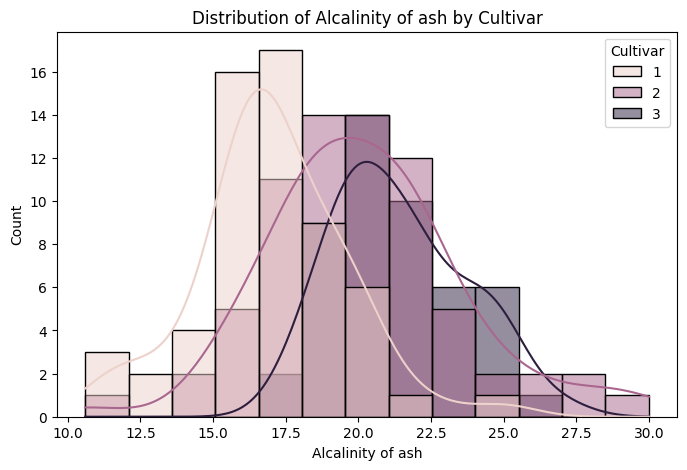

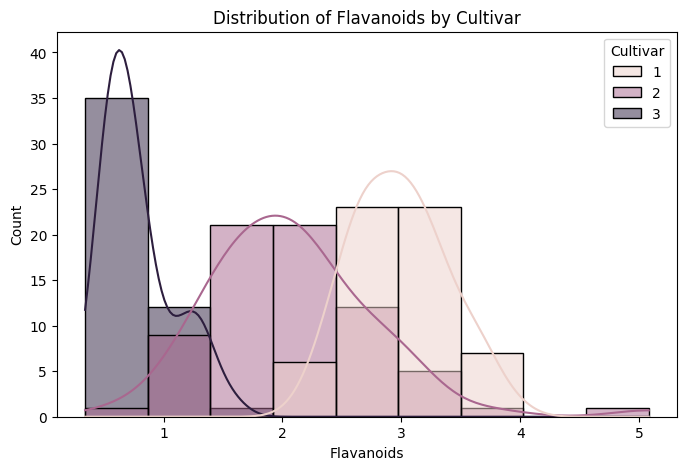

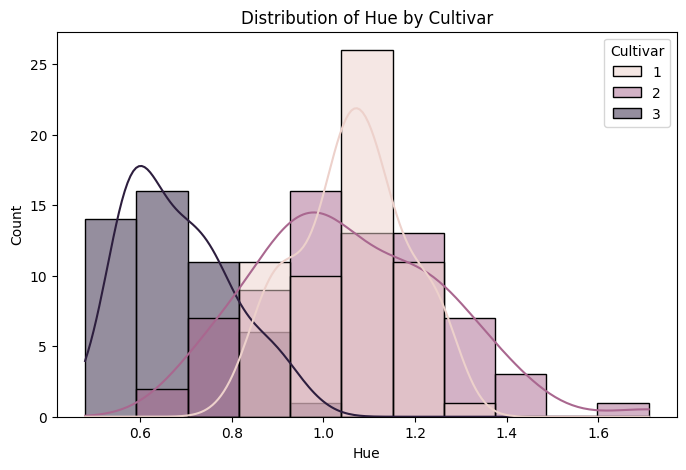

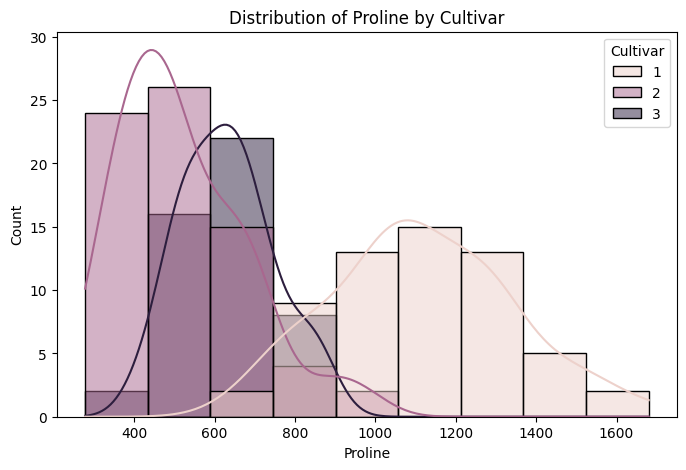

In [4]:
# 3. Distribution plots for 4 features
features_to_plot = [
    "Alcalinity of ash",
    "Flavanoids",
    "Hue",
    "Proline"
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df,
        x=feature,
        hue="Cultivar",
        kde=True
    )
    plt.title(f"Distribution of {feature} by Cultivar")
    plt.show()

In [5]:
# 4. PCA feature extraction

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Extract 4 principal components
pca_4 = PCA(n_components=4)
X_pca_4 = pca_4.fit_transform(X_scaled)

In [6]:
# a. Variance captured by each PC
print("Variance captured by each Principal Component:")
for i, var in enumerate(pca_4.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f} or {var * 100:.2f}%")

Variance captured by each Principal Component:
PC1: 0.3620 or 36.20%
PC2: 0.1921 or 19.21%
PC3: 0.1112 or 11.12%
PC4: 0.0707 or 7.07%


In [7]:
# b. Total variance captured by 4 PCs
total_variance_4 = pca_4.explained_variance_ratio_.sum()
print(f"\nTotal variance captured by 4 PCs: {total_variance_4:.4f}")
print(f"Total variance captured by 4 PCs: {total_variance_4 * 100:.2f}%")


Total variance captured by 4 PCs: 0.7360
Total variance captured by 4 PCs: 73.60%


In [8]:
# c. Minimum number of PCs to capture at least 85%
pca_all = PCA()
pca_all.fit(X_scaled)

cumulative_variance = pca_all.explained_variance_ratio_.cumsum()

min_components_85 = 0
for i, cum_var in enumerate(cumulative_variance, start=1):
    if cum_var >= 0.85:
        min_components_85 = i
        break

print(f"\nMinimum number of PCs required to capture at least 85% variance: {min_components_85}")


Minimum number of PCs required to capture at least 85% variance: 6


In [9]:
# d. Maximum number of PCs
max_components = min(X.shape[0], X.shape[1])
print(f"\nMaximum number of Principal Components: {max_components}")


Maximum number of Principal Components: 13
